
 Fold 1/5 (3-Class Classification)
APPLYING MIXUP AUGMENTATION...
Epoch 1/60
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6383 - loss: 1.1930
Epoch 1: val_loss improved from None to 0.65950, saving model to results_3Class_Final\best_model_fold1.keras
330/330 ━━━━━━━━━━━━━━━━━━━━ 83s 231ms/step - accuracy: 0.7546 - loss: 0.8612 - val_accuracy: 0.7823 - val_loss: 0.6595 - learning_rate: 1.0000e-04
Epoch 2/60
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8702 - loss: 0.6294
Epoch 2: val_loss improved from 0.65950 to 0.40333, saving model to results_3Class_Final\best_model_fold1.keras
330/330 ━━━━━━━━━━━━━━━━━━━━ 84s 255ms/step - accuracy: 0.8803 - loss: 0.6099 - val_accuracy: 0.9575 - val_loss: 0.4033 - learning_rate: 1.0000e-04
Epoch 3/60
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8970 - loss: 0.5779
Epoch 3: val_loss did not improve from 0.40333
330/330 ━━━━━━━━━━━━━━━━━━━━ 124s 376ms/step - accuracy: 0.9039 - loss: 0.5680 - val_accuracy: 0.9451 - v

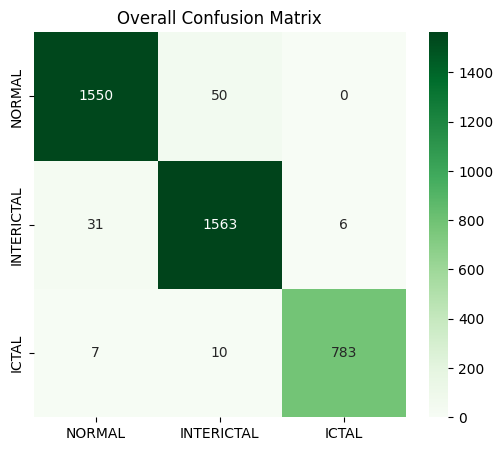


 Overall Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.97      0.97      1600
  INTERICTAL       0.96      0.98      0.97      1600
       ICTAL       0.99      0.98      0.99       800

    accuracy                           0.97      4000
   macro avg       0.98      0.97      0.98      4000
weighted avg       0.97      0.97      0.97      4000



In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    BatchNormalization, GlobalAveragePooling1D, Reshape, Multiply, 
    SpatialDropout1D, Concatenate, Add, GlobalMaxPooling1D, 
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

PREPROCESSING_DIR = r"Preprocessing_Updated_Kfold"
N_FOLDS = 5
RESULTS_DIR = "results_3Class_Final"
NUM_CLASSES = 3 
LABEL_MAP = {0: "NORMAL", 1: "INTERICTAL", 2: "ICTAL"}

os.makedirs(RESULTS_DIR, exist_ok=True)

def mixup_batch(X, y, alpha=0.4):
   
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    lam = np.random.beta(alpha, alpha, size=len(X)).astype(np.float32)
    
    if X.ndim == 2:
        lam_x = lam.reshape((len(X), 1))
    else:
        lam_x = lam.reshape((len(X), 1, 1))
        
    X_mix = X * lam_x + X[indices] * (1 - lam_x)
    
    lam_y = lam.reshape((len(X), 1))
    y_mix = y * lam_y + y[indices] * (1 - lam_y)
    
    return X_mix, y_mix

def augment_batch_advanced(X, y):
    
    X_aug, y_aug = [], []
    
    for i in range(len(X)):
        shift = np.random.randint(-5, 5)
        scale = np.random.uniform(0.97, 1.03)
        noise = np.random.normal(0, 0.005, X[i].shape).astype(np.float32)
        
        signal_mod = np.roll(X[i] + noise, shift) * scale
        
        X_aug.append(X[i])       
        y_aug.append(y[i]) 
        X_aug.append(signal_mod) 
        y_aug.append(y[i]) 
        
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.float32)
    
    X_mix, y_mix = mixup_batch(X_aug, y_aug)
    
    X_final = np.concatenate([X_aug, X_mix], axis=0)
    y_final = np.concatenate([y_aug, y_mix], axis=0)
    
    return X_final, y_final

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = Add()([x, inputs]) 

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Conv1D(ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(inputs.shape[-1], kernel_size=1)(x)
    x = Add()([x, res]) 
    return x

def inception_module(input_tensor, filters=32):
    conv1 = Conv1D(filters, kernel_size=3, padding='same', activation='relu')(input_tensor)
    conv2 = Conv1D(filters, kernel_size=5, padding='same', activation='relu')(input_tensor)
    conv3 = Conv1D(filters, kernel_size=11, padding='same', activation='relu')(input_tensor)
    pool = MaxPooling1D(3, strides=1, padding='same')(input_tensor)
    conv_pool = Conv1D(filters, kernel_size=1, padding='same', activation='relu')(pool)
    return Concatenate(axis=-1)([conv1, conv2, conv3, conv_pool])

def squeeze_excitation_block(input_tensor, ratio=4):
    channels = input_tensor.shape[-1]
    squeeze = GlobalAveragePooling1D()(input_tensor)
    excitation = Dense(channels // ratio, activation='relu')(squeeze)
    excitation = Dense(channels, activation='sigmoid')(excitation)
    excitation = Reshape((1, channels))(excitation)
    return Multiply()([input_tensor, excitation])

def build_3class_model(input_length):
    inputs = Input(shape=(input_length, 1))

    x = inception_module(inputs, filters=16)
    x = BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = MaxPooling1D(2)(x)
    x = SpatialDropout1D(0.1)(x)

    x = inception_module(x, filters=32)
    x = BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = MaxPooling1D(2)(x)
    x = SpatialDropout1D(0.15)(x)

    x = inception_module(x, filters=64)
    x = BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = MaxPooling1D(2)(x)
    x = SpatialDropout1D(0.2)(x)

    x = transformer_encoder(x, head_size=64, num_heads=8, ff_dim=256, dropout=0.2)
    
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])
    
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name="Inception_Transformer_3Class")
    
    model.compile(
        optimizer=Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

def predict_with_tta(model, X_test, iterations=4):
    preds = model.predict(X_test, verbose=0)
    for _ in range(iterations):
        X_aug = []
        for i in range(len(X_test)):
            shift = np.random.randint(-3, 3) 
            scale = np.random.uniform(0.98, 1.02)
            aug_sig = np.roll(X_test[i], shift) * scale
            X_aug.append(aug_sig)
        preds += model.predict(np.array(X_aug), verbose=0)
    return preds / (iterations + 1)

def plot_classification_report_heatmap(y_true, y_pred, title, save_path):
    target_names = [LABEL_MAP[0], LABEL_MAP[1], LABEL_MAP[2]]
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :].T
    plt.figure(figsize=(8, 5))
    sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.4f', cbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

acc_per_fold = []
conf_matrices = []
all_y_true = []
all_y_pred = []

for fold_no in range(N_FOLDS):
    print(f"\n{'='*60}\n Fold {fold_no + 1}/{N_FOLDS} (3-Class Classification)\n{'='*60}")
    
    checkpoint_path = os.path.join(RESULTS_DIR, f"best_model_fold{fold_no + 1}.keras")

    X_train_full = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_X_train.npy"), allow_pickle=True).astype(np.float32)
    y_train_full = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_y_train.npy"), allow_pickle=True).astype(np.int32)
    X_test = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_X_test.npy"), allow_pickle=True).astype(np.float32)
    y_test = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_y_test.npy"), allow_pickle=True).astype(np.int32)
    
    y_train_onehot = to_categorical(y_train_full, num_classes=NUM_CLASSES)
    y_test_onehot = to_categorical(y_test, num_classes=NUM_CLASSES)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_onehot, 
        test_size=0.1765, 
        stratify=y_train_full,
        random_state=42
    )

    print("APPLYING MIXUP AUGMENTATION...")
    X_train, y_train = augment_batch_advanced(X_train, y_train)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = build_3class_model(X_train.shape[1])
    
    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
    ]
    
    y_integers = np.argmax(y_train, axis=1)
    unique_classes = np.unique(y_integers)
    cw = compute_class_weight('balanced', classes=unique_classes, y=y_integers)
    class_weights = {cls: weight for cls, weight in zip(unique_classes, cw)}

    model.fit(
        X_train, y_train, 
        epochs=60, 
        batch_size=32, 
        validation_data=(X_val, y_val), 
        callbacks=callbacks,
        class_weight=class_weights, 
        verbose=1
    )

    print(f"Loading best weights & Evaluating Fold {fold_no + 1}...")
    model.load_weights(checkpoint_path)
    
    y_probs = predict_with_tta(model, X_test)
    y_pred = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_test_onehot, axis=1)
    
    acc = np.mean(y_pred == y_true)
    print(f"Accuracy: {acc:.4f}")
    acc_per_fold.append(acc)
    
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    
    conf_matrices.append(confusion_matrix(y_true, y_pred))
    
    plot_classification_report_heatmap(
        y_true, y_pred, 
        f"Fold {fold_no + 1} Report", 
        os.path.join(RESULTS_DIR, f"report_fold{fold_no + 1}.png")
    )
    
    K.clear_session()
    gc.collect()

print(f"\n FINAL MEAN ACCURACY: {np.mean(acc_per_fold):.4f} =+ {np.std(acc_per_fold):.4f}")

total_cm = np.sum(conf_matrices, axis=0)
plt.figure(figsize=(6, 5))
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=[LABEL_MAP[0], LABEL_MAP[1], LABEL_MAP[2]], 
            yticklabels=[LABEL_MAP[0], LABEL_MAP[1], LABEL_MAP[2]])
plt.title("Overall Confusion Matrix")
plt.savefig(os.path.join(RESULTS_DIR, "overall_conf_matrix.png"))
plt.show()

print("\n Overall Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=[LABEL_MAP[0], LABEL_MAP[1], LABEL_MAP[2]]))

plot_classification_report_heatmap(
    all_y_true, all_y_pred, 
    "Overall Consolidated Report", 
    os.path.join(RESULTS_DIR, "overall_classification_report.png")
)